In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Робимо графіки трохи більшими
plt.rcParams['figure.figsize'] = (10, 5)

# Функція-помічник: робить всю брудну роботу (навчає, рахує, малює)
def show_results(X, y, title, x_label, y_label):
    # Створюємо модель і вчимо її
    model = LinearRegression()
    model.fit(X, y)
    
    # Робимо прогноз
    y_pred = model.predict(X)
    
    # Рахуємо точність 
    r2 = r2_score(y, y_pred)
    print(f"📊 {title}")
    print(f"   Точність моделі (R2): {r2:.4f}")
    
    # Малюємо графік
    plt.scatter(X, y, color='blue', alpha=0.5, label='Фактичні дані') # Точки
    plt.plot(X, y_pred, color='red', linewidth=2, label='Лінія тренду') # Лінія
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

--- ЗАВДАННЯ 1: Створення свого Dataset ---
✅ Файл 'task1_data.csv' створено.
📊 Завдання 1: Вплив сну на енергію
   Точність моделі (R2): 0.8875


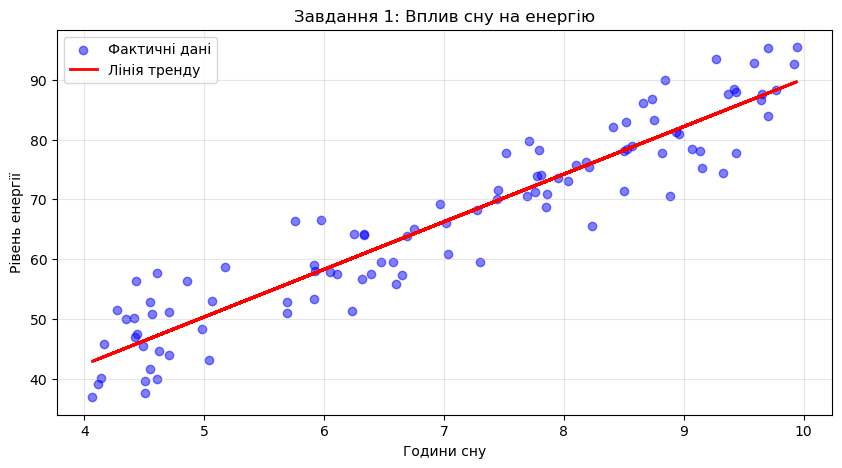

In [8]:
print("--- ЗАВДАННЯ 1: Створення свого Dataset ---")

# 1. Придумуємо дані (100 студентів)
data = {
    'Sleep': np.random.uniform(4, 10, 100), # Сплять від 4 до 10 годин
}
# Енергія залежить від сну + трохи випадковості (шум)
data['Energy'] = 10 + 8 * data['Sleep'] + np.random.normal(0, 5, 100)

# 2. Зберігаємо у файл (вимога методички)
df_gen = pd.DataFrame(data)
df_gen.to_csv('task1_data.csv', index=False)
print("✅ Файл 'task1_data.csv' створено.")

# 3. Аналізуємо
df1 = pd.read_csv('task1_data.csv')
show_results(df1[['Sleep']], df1['Energy'], 
             "Завдання 1: Вплив сну на енергію", "Години сну", "Рівень енергії")

--- ЗАВДАННЯ 2: Робота з Kaggle (Fish.csv) ---
📊 Завдання 2: Рибний ринок
   Точність моделі (R2): 0.8385


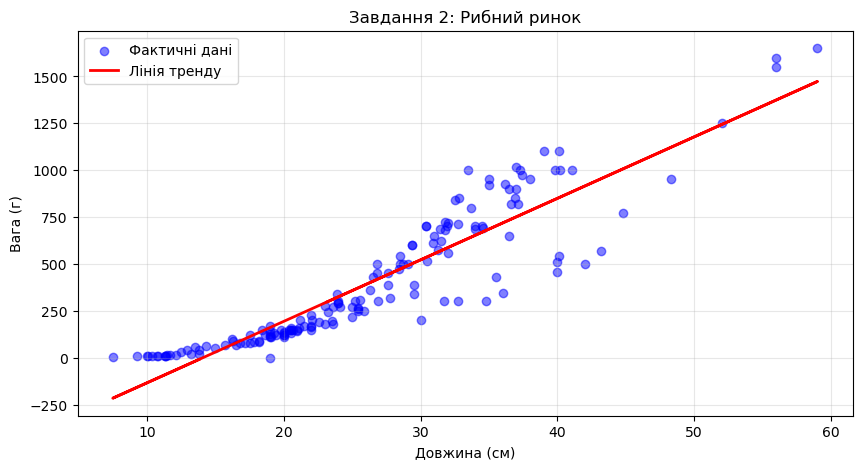

In [9]:
print("--- ЗАВДАННЯ 2: Робота з Kaggle (Fish.csv) ---")

# Перевіряємо, чи є файл у папці
if os.path.exists('Fish.csv'):
    # 1. Завантажуємо
    df_fish = pd.read_csv('Fish.csv')
    
    # 2. Обираємо дані: Довжина (Length1) впливає на Вагу (Weight)
    X_fish = df_fish[['Length1']] 
    y_fish = df_fish['Weight']
    
    # 3. Запускаємо аналіз
    show_results(X_fish, y_fish, 
                 "Завдання 2: Рибний ринок", "Довжина (см)", "Вага (г)")
else:
    print("❌ Помилка: Файл 'Fish.csv' не знайдено! Перетягніть його в папку.")

--- ЗАВДАННЯ 3: Python Generation (Numpy) ---
📊 Завдання 3: Швидкість vs Час
   Точність моделі (R2): 0.9363


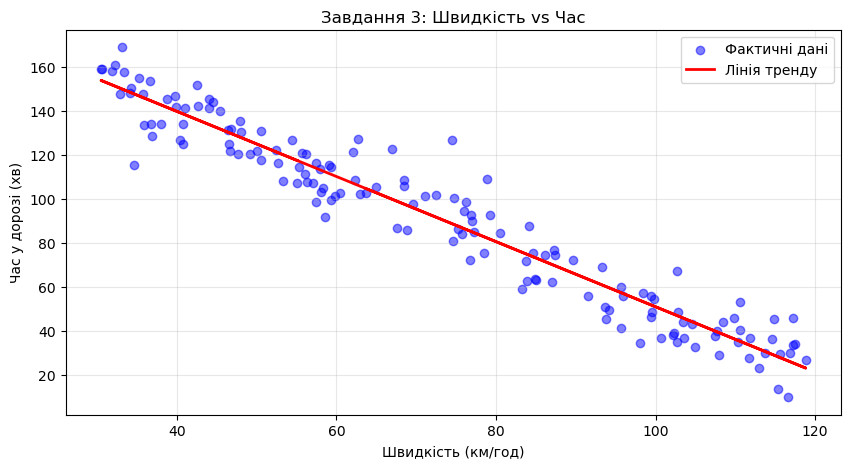

In [10]:
print("--- ЗАВДАННЯ 3: Python Generation (Numpy) ---")

# 1. Генеруємо 150 випадкових поїздок
np.random.seed(42)
X_speed = 30 + 90 * np.random.rand(150, 1) # Швидкість 30-120 км/год

# 2. Рахуємо час: чим вища швидкість, тим менше часу
# (200 - час, 1.5 - коефіцієнт зменшення)
y_time = 200 - 1.5 * X_speed + np.random.randn(150, 1) * 10

# 3. Аналізуємо
show_results(X_speed, y_time, 
             "Завдання 3: Швидкість vs Час", "Швидкість (км/год)", "Час у дорозі (хв)")